# Spam Detection with TF-IDF and Linear SVM

**CSE 143 — NLP Final Project**

This project builds a spam detector for text messages and emails. The idea is
to turn each message into numbers with TF-IDF, then train a Linear SVM to guess
if the message is `ham` (normal) or `spam`.

We run the same steps on two datasets so we can compare them:

- **SMS messages** — short text messages.
- **Emails** — longer messages from the Enron email dataset (subject + body).

For each dataset we report accuracy, precision, recall, F1, and F2, draw a
confusion matrix, and run 5-fold cross-validation. At the end we also compare
the SVM against two simpler models (Naive Bayes and Logistic Regression).

The reusable code is in the `src/` folder so the notebook stays short.

## 2. Load Libraries and Project Functions

We import the usual data and plotting libraries, plus our own helper functions
from `src/`. Keeping the code in `src/` means the notebook is mostly about
showing the results.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Our reusable project functions
from src.preprocessing import load_sms_data, load_enron_data, prepare_dataset
from src.modeling import (
    build_svm_pipeline,
    build_nb_pipeline,
    build_logreg_pipeline,
    train_test_model,
    cross_validate_model,
)
from src.evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    save_metrics_summary,
    print_classification_report,
)

# Make sure the results folder exists for the saved plots and CSV
os.makedirs("results", exist_ok=True)

# Make plots a little cleaner
sns.set_theme(style="whitegrid")

## 3. Load and Prepare the SMS Dataset

The SMS Spam Collection is a set of real text messages labeled `ham` or `spam`.
The file is tab-separated with no header: column 1 is the label and column 2 is
the message.

We load it and then use `prepare_dataset` to clean the text (lowercase, replace
URLs/emails/numbers with tokens, and drop empty rows).

In [2]:
# loading dataset
sms_raw = load_sms_data("data/sms_spam_collection.tsv")

# cleaning data set
sms_df = prepare_dataset(sms_raw)

# small preview of data set
print(f"SMS dataset: {len(sms_df)} messages")
sms_df.head()

SMS dataset: 5572 messages


,text,label
0,"go until jurong point, crazy.. available only ...",ham
1,ok lar... joking wif u oni...,ham
2,free entry in NUMBER a wkly comp to win fa cup...,spam
3,u dun say so early hor... u c already then say...,ham
4,"nah i don't think he goes to usf, he lives aro...",ham


label
ham     4825
spam     747
Name: count, dtype: int64


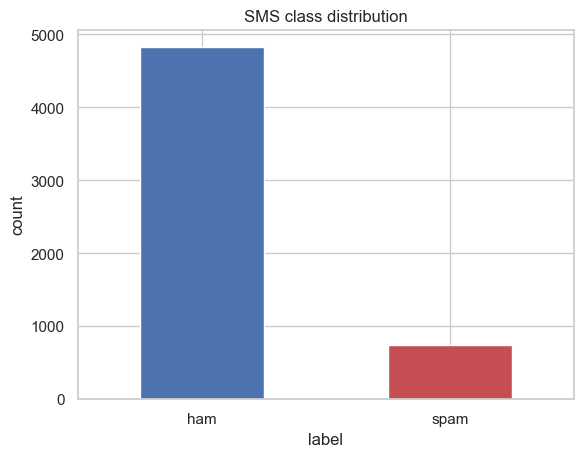

In [3]:
# Quick view of distribution, amount of ham vs spam
print(sms_df["label"].value_counts())

sms_df["label"].value_counts().plot(kind="bar", color=["#4c72b0", "#c44e52"])
plt.title("SMS class distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

The SMS dataset is imbalanced: most messages are `ham` and fewer are `spam`.
That is why we use `class_weight="balanced"`, which gives more weight to the smaller class to limit bias toward the larger class, and why we look at recall and F2,
not just accuracy.

## 4. SMS Experiment: TF-IDF + Linear SVM

Now we build the main pipeline (TF-IDF + LinearSVC), split the data 80/20 with a
stratified split, train, and check the results.

In [4]:
# Build the main model and train/evaluate it on the SMS data
sms_svm = build_svm_pipeline(ngram_range=(1, 2), analyzer="word")

# 80% training 20% testing split
sms_model, X_train, X_test, y_train, y_test, y_pred = train_test_model(sms_df, sms_svm, test_size=0.2, random_state=42)

# Get our five metrics on the test set
sms_metrics = calculate_metrics(y_test, y_pred)
sms_metrics

{'accuracy': 0.9865470852017937,
 'precision': 0.9407894736842105,
 'recall': 0.959731543624161,
 'f1': 0.9501661129568106,
 'f2': 0.9558823529411765}

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.96      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115



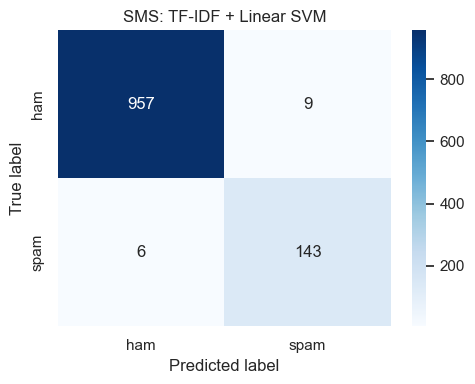

In [5]:
# Detailed per-class report
print_classification_report(y_test, y_pred)

# Confusion matrix, saved to the results folder
plot_confusion_matrix(
    y_test,
    y_pred,
    title="SMS: TF-IDF + Linear SVM",
    save_path="results/sms_confusion_matrix.png",
)

## 5. SMS Cross-Validation

One train/test split can be lucky or unlucky. 5-fold cross-validation splits the
data five ways and averages the results, which is more trustworthy. We report
the mean and standard deviation for each metric.

In [6]:
# Run 5-fold cross-validation with a fresh pipeline
sms_cv = cross_validate_model(sms_df, build_svm_pipeline(), cv=5)

# Show it as a table (mean and std per metric)
pd.DataFrame(sms_cv, index=["SMS SVM"]).T

,SMS SVM
accuracy_mean,0.983488
accuracy_std,0.003484
precision_mean,0.929264
precision_std,0.014520
recall_mean,0.949119
recall_std,0.012480
f1_mean,0.939068
f1_std,0.012904
f2_mean,0.945068
f2_std,0.012480


## 6. Load and Prepare the Enron Email Dataset

The Enron email dataset has real emails labeled spam or ham. Each email has a
`Subject` and a `Message`. Our `load_enron_data` function joins these into one
text field and reads the label from the `Spam/Ham` column. Then `prepare_dataset`
cleans it the same way as the SMS data.

In [7]:
# Load and clean the Enron email data
enron_raw = load_enron_data("data/enron_spam_data.csv")
enron_df = prepare_dataset(enron_raw)

print(f"Enron dataset: {len(enron_df)} emails")
enron_df.head()

Enron dataset: 33716 emails


,text,label
0,christmas tree farm pictures,ham
1,"vastar resources , inc . gary , production fro...",ham
2,calpine daily gas nomination - calpine daily g...,ham
3,re : issue fyi - see note below - already done...,ham
4,meter NUMBER nov allocation fyi . - - - - - - ...,ham


label
spam    17171
ham     16545
Name: count, dtype: int64


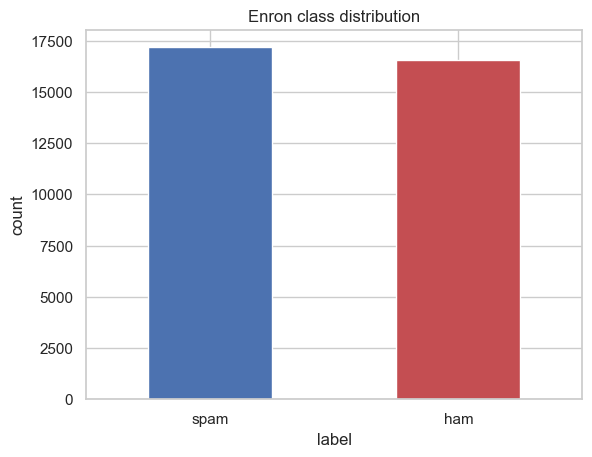

In [8]:
# Class distribution for the email dataset
print(enron_df["label"].value_counts())

enron_df["label"].value_counts().plot(kind="bar", color=["#4c72b0", "#c44e52"])
plt.title("Enron class distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

The Enron dataset is much bigger than SMS and is pretty balanced between ham and
spam. The emails are also longer, so TF-IDF has more text to work with.

## 7. Enron Experiment: TF-IDF + Linear SVM

Same pipeline as before, now on the email data.

In [9]:
# Build and train the SVM on the email data
enron_svm = build_svm_pipeline(ngram_range=(1, 2), analyzer="word")

enron_model, eX_train, eX_test, ey_train, ey_test, ey_pred = train_test_model(
    enron_df, enron_svm, test_size=0.2, random_state=42
)

enron_metrics = calculate_metrics(ey_test, ey_pred)
enron_metrics

{'accuracy': 0.9994068801897983,
 'precision': 0.9988368711834835,
 'recall': 1.0,
 'f1': 0.9994180971777713,
 'f2': 0.9997671575761103}

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00      3309
        spam       1.00      1.00      1.00      3435

    accuracy                           1.00      6744
   macro avg       1.00      1.00      1.00      6744
weighted avg       1.00      1.00      1.00      6744



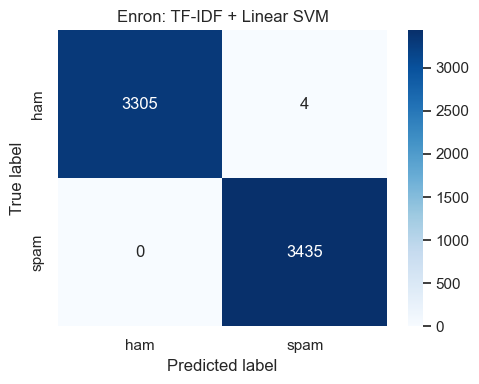

In [10]:
print_classification_report(ey_test, ey_pred)

plot_confusion_matrix(
    ey_test,
    ey_pred,
    title="Enron: TF-IDF + Linear SVM",
    save_path="results/enron_confusion_matrix.png",
)

## 8. Enron Cross-Validation

5-fold cross-validation on the email dataset.

In [11]:
# 5-fold cross-validation on the email data
enron_cv = cross_validate_model(enron_df, build_svm_pipeline(), cv=5)

pd.DataFrame(enron_cv, index=["Enron SVM"]).T

,Enron SVM
accuracy_mean,0.999466
accuracy_std,0.000201
precision_mean,0.998953
precision_std,0.000394
recall_mean,1.000000
recall_std,0.000000
f1_mean,0.999476
f1_std,0.000197
f2_mean,0.999790
f2_std,0.000079


## 9. Model Interpretability

Because our main model is a Linear SVM, we can look directly at the weights it
learned. Each TF-IDF feature (a word or short phrase) gets a weight:

- **Positive weights** push the model toward `spam`.
- **Negative weights** push the model toward `non-spam`.

Looking at these weights helps us understand what kinds of words and phrases the
model learned from the TF-IDF features.

In [12]:
from src.interpretability import get_top_features, explain_single_prediction

# top words the SMS model links with spam vs non-spam
sms_spam_features, sms_nonspam_features = get_top_features(sms_model, top_n=15)

print("Top SMS spam features:")
display(sms_spam_features)
print("Top SMS non-spam features:")
display(sms_nonspam_features)

Top SMS spam features:


,feature,weight
0,number,3.110050
1,url,2.584774
2,mobile,1.894670
3,txt,1.804613
4,reply,1.714110
5,service,1.686610
6,uk,1.637503
7,text,1.436566
8,stop,1.399961
9,ringtone,1.245186


Top SMS non-spam features:


,feature,weight
0,ok,-0.775309
1,lt,-0.745220
2,hey,-0.714917
3,gt,-0.696062
4,got,-0.655656
5,lt gt,-0.608312
6,ll,-0.606296
7,home,-0.600525
8,work,-0.534712
9,lor,-0.525266


In [13]:
# top words the Enron email model links with spam vs non-spam
enron_spam_features, enron_nonspam_features = get_top_features(enron_model, top_n=15)

print("Top Enron spam features:")
display(enron_spam_features)
print("Top Enron non-spam features:")
display(enron_nonspam_features)

Top Enron spam features:


,feature,weight
0,ubs,1.436783
1,trdts,1.129517
2,trdts number,1.129517
3,machine nahou,1.129517
4,nahou trdts,1.129517
5,nahou,1.122552
6,ivanhoe,0.949593
7,admin machine,0.849344
8,locked user,0.849344
9,user admin,0.849111


Top Enron non-spam features:


,feature,weight
0,locked table,-1.543735
1,ecthou bps,-0.848387
2,machine ecthou,-0.848387
3,bps number,-0.827636
4,bps,-0.810682
5,ecthou,-0.796347
6,randy sent,-0.486930
7,message lebeau,-0.486930
8,number watson,-0.412902
9,user transaction,-0.362176


The SMS spam features include words and phrases that often show up in
promotional or scam-like messages (prizes, free offers, and urgent calls to
action). The non-spam features are more casual and conversation-based, which
makes sense because many normal SMS messages are just personal conversations.
The Enron email features follow the same idea: spam words are tied to marketing
and scams, while non-spam words are tied to normal work emails.

In [14]:
# explain one spam-like message
example_message = "urgent winner claim your free prize now"
explain_single_prediction(sms_model, example_message, top_n=10)

,feature,tfidf,weight,contribution,direction
0,claim,0.339809,1.082604,0.367879,spam
1,prize,0.366767,0.953092,0.349562,spam
2,winner,0.468780,0.484298,0.227029,spam
3,free,0.290620,0.704996,0.204886,spam
4,urgent,0.370262,0.553103,0.204793,spam
5,claim free,0.555611,0.201724,0.112080,spam


This table shows the strongest TF-IDF features from the message and whether they
pushed the model toward spam or non-spam.

In [15]:
# explain a normal-looking message for comparison
example_message = "hey are we still meeting tomorrow for lunch"
explain_single_prediction(sms_model, example_message, top_n=10)

,feature,tfidf,weight,contribution,direction
0,hey,0.445022,-0.714917,-0.318154,non-spam
1,lunch,0.545976,-0.336354,-0.183641,non-spam
2,meeting,0.529389,-0.193336,-0.102350,non-spam
3,tomorrow,0.472877,-0.146924,-0.069477,non-spam


## 10. Optional Model Comparison

Is the Linear SVM really better than simpler models? Here we compare it against
Naive Bayes and Logistic Regression on both datasets using the same train/test
split. We put every result in one list and save it as a CSV.

In [16]:
# Train one model on one dataset and return a row of results
def run_experiment(dataset_name, model_name, df, model):
    _, _, _, _, y_te, y_pr = train_test_model(df, model)
    metrics = calculate_metrics(y_te, y_pr)
    return {"dataset": dataset_name, "model": model_name, **metrics}


# The three models we want to compare
def make_models():
    return {
        "Linear SVM": build_svm_pipeline(),
        "Naive Bayes": build_nb_pipeline(),
        "Logistic Regression": build_logreg_pipeline(),
    }


results_list = []
for dataset_name, df in [("SMS", sms_df), ("Enron", enron_df)]:
    for model_name, model in make_models().items():
        results_list.append(run_experiment(dataset_name, model_name, df, model))

# Save the full table to the results folder and show it
summary_df = save_metrics_summary(results_list, "results/metrics_summary.csv")
summary_df

,dataset,model,accuracy,precision,recall,f1,f2
0,SMS,Linear SVM,0.986547,0.940789,0.959732,0.950166,0.955882
1,SMS,Naive Bayes,0.967713,1.000000,0.758389,0.862595,0.796897
2,SMS,Logistic Regression,0.956054,0.777778,0.939597,0.851064,0.902062
3,Enron,Linear SVM,0.999407,0.998837,1.000000,0.999418,0.999767
4,Enron,Naive Bayes,0.980872,0.963805,1.000000,0.981569,0.992545
5,Enron,Logistic Regression,0.999259,0.998547,1.000000,0.999273,0.999709


## 11. Results Summary

Here is the comparison table, rounded so it is easier to read. The numbers come
from the experiments above.

In [17]:
# Round the metric columns to 3 decimals so the table reads nicely
metric_cols = ["accuracy", "precision", "recall", "f1", "f2"]
summary_display = summary_df.copy()
summary_display[metric_cols] = summary_display[metric_cols].round(3)
summary_display

,dataset,model,accuracy,precision,recall,f1,f2
0,SMS,Linear SVM,0.987,0.941,0.960,0.950,0.956
1,SMS,Naive Bayes,0.968,1.000,0.758,0.863,0.797
2,SMS,Logistic Regression,0.956,0.778,0.940,0.851,0.902
3,Enron,Linear SVM,0.999,0.999,1.000,0.999,1.000
4,Enron,Naive Bayes,0.981,0.964,1.000,0.982,0.993
5,Enron,Logistic Regression,0.999,0.999,1.000,0.999,1.000


**How to read this table:** all three models do pretty well, which means TF-IDF
features already carry a lot of signal for spam. The Linear SVM is usually at or
near the top, especially on F1 and F2, and it keeps a good balance between
catching spam (recall) and not flagging normal messages (precision). Naive Bayes
is a fast baseline but often has lower recall, and Logistic Regression is close
to the SVM.

## 11. Discussion

**Why TF-IDF + SVM works well.** Spam uses very recognizable words like "free",
"win", "click", and "prize". TF-IDF gives high weight to words that show up a lot
in one message but are rare overall, so these spammy words stand out. This gives
a big, sparse set of features, and Linear SVMs handle that kind of data well
without overfitting too much.

**Precision vs. recall.** In spam detection these pull in opposite directions:

- **Precision** = of the messages we flagged as spam, how many really were spam?
  Low precision means we wrongly flag normal messages (false positives).
- **Recall** = of all the real spam, how much did we catch? Low recall means spam
  slips into the inbox (false negatives).

**Why F2 is useful here.** F1 treats precision and recall equally. F2 weights
recall about twice as much as precision. For spam, missing spam is usually worse
than a false alarm, so F2 rewards models that catch more spam, which is what we
want.

**Cost of mistakes.** A false positive (a real message marked as spam) means the
user might miss something important. A false negative (spam that gets through) is
annoying and can be dangerous (phishing/scams). F2 leans toward catching more
spam.

## 12. Word vs Character N-Grams

So far our model used **word n-grams**: full words and short phrases like
"free" or "call now". Another option is **character n-grams**, which look at
small character patterns inside words (like "fre", "ree!", "w1n").

Character n-grams can help with spam that intentionally misspells words to
sneak past filters, like "fr33", "w1nner", or "cl!ck". Even if the full word is
new, the character patterns inside it can still look spammy.

Here we compare three SVM models on the SMS data:

1. **Word TF-IDF SVM** — word n-grams only (our main model)
2. **Character TF-IDF SVM** — character n-grams only
3. **Word + Character TF-IDF SVM** — both feature sets combined

We focus this experiment on SMS because short text and weird spelling are more
common in text messages than in emails.

In [18]:
from src.modeling import build_combined_svm_pipeline

# The three n-gram setups we want to compare on the SMS data
ngram_models = {
    "Word TF-IDF SVM": build_svm_pipeline(ngram_range=(1, 2), analyzer="word"),
    "Character TF-IDF SVM": build_svm_pipeline(ngram_range=(3, 5), analyzer="char"),
    "Word + Character TF-IDF SVM": build_combined_svm_pipeline(),
}

# Train and test each one with the same split, then collect the metrics
ngram_results = []
for name, ngram_model in ngram_models.items():
    _, _, _, _, ng_y_test, ng_y_pred = train_test_model(sms_df, ngram_model)
    ngram_results.append({"model": name, **calculate_metrics(ng_y_test, ng_y_pred)})

ngram_df = pd.DataFrame(ngram_results)

# Save the table to the results folder
ngram_df.to_csv("results/ngram_comparison.csv", index=False)

# Rounded copy so the table is easier to read
ngram_display = ngram_df.copy()
ngram_display[metric_cols] = ngram_display[metric_cols].round(3)
ngram_display

,model,accuracy,precision,recall,f1,f2
0,Word TF-IDF SVM,0.987,0.941,0.960,0.950,0.956
1,Character TF-IDF SVM,0.990,0.973,0.953,0.963,0.957
2,Word + Character TF-IDF SVM,0.991,0.979,0.953,0.966,0.958


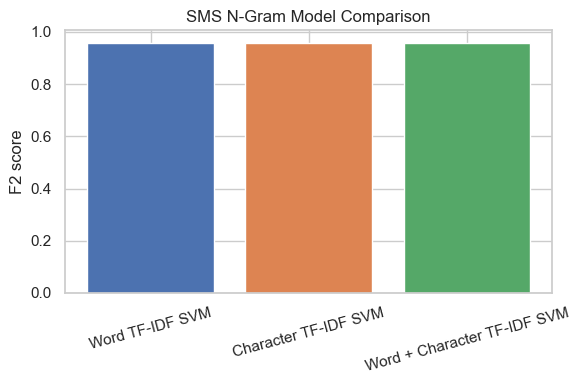

In [19]:
# Simple bar chart comparing the three models by F2 score
plt.figure(figsize=(6, 4))
plt.bar(ngram_df["model"], ngram_df["f2"], color=["#4c72b0", "#dd8452", "#55a868"])
plt.ylabel("F2 score")
plt.title("SMS N-Gram Model Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results/ngram_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

All three setups score well, which shows that spam signal lives at both the
word level and the character level. Character n-grams alone are surprisingly
strong because they can match pieces of spammy words even when the exact word
was never seen in training. The combined model gets both kinds of evidence, so
it is a nice option when spam uses creative spelling to dodge word-based
filters.

## 13. Limitations and Future Work

- **The datasets are old.** The Enron emails are from the early 2000s and the SMS
  set is also old, so the words may not match today's spam.
- **SMS and email are different.** A model trained on one would not work great on
  the other, so we trained a separate model for each.
- **Text only.** We only use the message text, not the sender, links, or
  attachments that real spam filters also use.
- **Modern spam is harder.** Phishing and AI-generated spam can look a lot like
  normal messages and might slip past a bag-of-words model.

**Future work** could include better preprocessing (like stemming), adding extra
features (sender, links, time), using larger and newer datasets, or trying
transformer models.

## 13. Conclusion

We built a simple spam detector using TF-IDF + Linear SVM and tested it on SMS
messages and Enron emails. It does well on both and usually matches or beats the
Naive Bayes and Logistic Regression baselines. Using a scikit-learn Pipeline kept
TF-IDF from leaking the test data, and looking at precision, recall, F1, and F2
told us more than accuracy alone. Overall, for classic text spam, simple linear
models on TF-IDF features are a strong and easy-to-explain choice.